# Quantile Mapping: A Fitted, Cross-Validated Baseline

**CMIP6 temperature downscaled to ERA5-Land resolution** · Eastern Mediterranean
and Middle East (24–38°N, 30–38°E) · 1990–1999

This notebook reports a fitted quantile-mapping baseline. Earlier work measured
how far each coarse-to-fine predictor sat from the observations but never fitted
a correction, so there was nothing to score out of sample. Here six
transforms are fitted per land pixel and season, and every number reported comes
from a held-out year.

The design is fixed on three axes so the comparison isolates the transform:

| Axis | Choice |
|---|---|
| Predictor | Bilinear regridding of CMIP6 TAS onto the ERA5-Land grid |
| Distribution window | Meteorological season, DJF / MAM / JJA / SON |
| Evaluation | Percentiles 5, 25, 50, 75, 90 |

All computation lives in `src/` and in `scripts/run_qm_transforms.py`. This
notebook loads the cached results, draws the figures and states what they show.

**Contents**

0. Environment setup
1. Method
2. The shape of the daily distribution
3. The fitted transforms at one pixel
4. Method comparison
5. Where the error sits in space
6. What limits the result

## 0. Environment setup

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src import qm_cv as qcv
from src import qm_eval as qev
from src import qm_inputs as qin
from src import qm_nodes as qn
from src import qm_transform_viz as tviz
from src import quantile_windows as qw
from src.qm_transforms import TRANSFORMS

DATA_DIR = ROOT / "data"
CACHE_DIR = DATA_DIR / "cache"
QM_DIR = CACHE_DIR / "qm"
TR_DIR = QM_DIR / "transforms"
PLOT_DIR = ROOT / "plots"
PLOT_DIR.mkdir(exist_ok=True)

REGION = qin.REGION
PERCENTILES = list(qw.PERCENTILES)
SEASONS = list(qn.SEASONS)

if not (TR_DIR / "qq_metrics_summary.parquet").exists():
    raise FileNotFoundError(
        "Transform results are missing. Run:\n"
        "    python3.10 scripts/run_qm_transforms.py"
    )

summary = pd.read_parquet(TR_DIR / "qq_metrics_summary.parquet")
pixel_err = pd.read_parquet(TR_DIR / "qq_per_pixel_error.parquet")
floor = pd.read_parquet(TR_DIR / "qq_obs_floor.parquet")
moments = pd.read_parquet(TR_DIR / "qq_daily_moments.parquet")
pixels = pd.read_parquet(TR_DIR / "qq_pixels.parquet")
manifest = json.loads((TR_DIR / "qq_manifest.json").read_text())

hyper = pd.concat(
    [pd.read_parquet(p) for p in sorted(TR_DIR.glob("qq_hyper_*.parquet"))],
    ignore_index=True,
) if list(TR_DIR.glob("qq_hyper_*.parquet")) else pd.DataFrame()

METHODS = [m for m in tviz.METHOD_LABELS if m in set(summary["method"])]

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)

print(f"{len(pixels):,} land pixels | methods: {', '.join(METHODS)}")
print(f"nodes: {manifest['config']['n_nodes']} | "
      f"extrapolation: {manifest['config']['extrap']} | "
      f"run took {manifest['total_seconds'] / 60:.1f} min")

7,683 land pixels | methods: raw, normal, linear, poly, quant, rquant, ssplin
nodes: 99 | extrapolation: boe | run took 4.6 min


## 1. Methods

### 1.1 Unit of fitting

A transform `h` maps a predictor value to a corrected value so that the
predicted distribution matches the observed one. Its general form is the
probability integral transform

$$\hat{y} = F_{obs}^{-1}\big(F_{mod}(x)\big)$$

where both cumulative distribution functions come from the calibration sample.
One `h` is fitted per **(land pixel, season)** on the pooled daily values of the
training years — about 810 to 828 days. All five percentiles are then read off
that single transform.

Percentile is an evaluation dimension, not a model dimension. A single
increasing `h` keeps the corrected percentiles in order, and a per-percentile
model would have only ten training points.

### 1.2 Models

Six fitted transforms, grouped as in Gudmundsson et al. (2012), plus the
uncorrected predictor as a reference.

In [2]:
rows = []
for name in METHODS:
    cls = TRANSFORMS[name]
    grid = cls.hp_grid
    rows.append({
        "method": tviz.METHOD_LABELS[name],
        "family": tviz.METHOD_FAMILIES[name],
        "form": {
            "raw": "no correction",
            "normal": "mu_y + (sd_y / sd_x) (x - mu_x)",
            "linear": "a + b x",
            "poly": "polynomial of degree d",
            "quant": "empirical percentile lookup, linear between nodes",
            "rquant": "as QUANT, nodes smoothed by local linear regression",
            "ssplin": "cubic smoothing spline",
        }[name],
        "hyper-parameter": ", ".join(f"{k} in {v}" for k, v in grid.items()) or "-",
    })
methods_table = pd.DataFrame(rows)
methods_table

,method,family,form,hyper-parameter
0,No correction,none,no correction,-
1,Normal,distribution derived,mu_y + (sd_y / sd_x) (x - mu_x),-
2,Linear,parametric,a + b x,-
3,Polynomial,parametric,polynomial of degree d,"degree in [2, 3, 4, 5]"
4,QUANT,non-parametric,"empirical percentile lookup, linear between nodes","n_nodes in [11, 19, 49, 99]"
5,RQUANT,non-parametric,"as QUANT, nodes smoothed by local linear regre...","wsize in [3, 5, 9, 15, 25, 41, 65]"
6,SSPLIN,non-parametric,cubic smoothing spline,"lam in [0.01, 0.1, 1.0, 10.0, 100.0]"


**Table 1.** *The transforms compared.* Family follows the classification of
Gudmundsson et al. (2012) into distribution-derived, parametric and
non-parametric transformations. The uncorrected bilinear predictor is carried
through the same evaluation as a reference. Hyper-parameter ranges are the grids
searched; a dash means the form has no free choice beyond its fitted parameters.

### 1.3 Distribution window

The season is the unit over which a distribution is estimated. Two reasons for
stratifying by season rather than pooling the whole year.

Pooled over a year, daily temperature at a fixed pixel is bimodal because the
annual cycle dominates it, so no parametric form applies. Within a season it is
unimodal; Section 2 reports the residual departure from normality.

Sub-annual stratification is standard practice. Lange (2019) adjusts per
variable, per grid cell and per calendar month. Lehner et al. (2023) state that
"the daily data of each grid cell of the model are adjusted separately with the
observations on a monthly basis."
Reiter et al. (2018) tested the choice deliberately, across four methods and four
timescales on 40 years of data, and found that "calibrating QM with subsamples
instead of the calibration data as a whole resulted in a clear benefit."

Their more useful finding is where that benefit stops. In sample, finer was always
better. Out of sample the gain flattened, and the best timescale depended on the
method. At monthly resolution the more flexible methods fitted calibration
extremes well but corrected independent-data extremes "to unrealistically high
values" — fine subsampling plus a flexible method overfits, invisibly until you
score out of sample.

Month would be finer than season. We use season because the record is ten years:
a calendar month gives about 300 training days, a season about 820. Lehner et al.
note that 30 years is the typical calibration length "since the statistical
distribution of data of a shorter time period can be very noisy." At ten years
that caution applies directly, and Reiter et al. imply the finer window would buy
little out of sample while raising the overfitting risk.

### 1.4 Cross-validation

Leave-one-season-year-out. For each season, one season-year is held out, the
transform is fitted on the rest, and the corrected percentiles of the held-out
year are compared with the observed ones.

Folds are whole seasons, not random days. Daily temperature is correlated over
roughly a week, so holding out single days would leave a test day's neighbours in
the training set and the transform would effectively be fitted on the test data.

Seasons are grouped by *season-year*, with December counted into the following
year's winter: December 1990 with January and February 1991 makes `1991-DJF`.
Holding out a season-year therefore removes its December too, so no fold leaks
across the calendar-year boundary.

This costs one winter. A complete DJF needs a December from the preceding
calendar year, so January-February 1990 and December 1999 are incomplete and are
dropped. **DJF has 9 folds and the other seasons have 10.**

In [3]:
rows = []
for season in SEASONS:
    w, codes = qw.make_windows(
        pd.date_range("1990-01-01", "1999-12-31", freq="D")
        .drop(pd.Timestamp("1992-02-29")).drop(pd.Timestamp("1996-02-29"))
        .strftime("%Y-%m-%d").tolist(),
        qw.SEASON_SCHEME,
    )
    sw = w[w["label"].str.endswith(season)]
    rows.append({
        "season": season,
        "months": tviz.SEASON_LABELS[season],
        "folds": len(sw),
        "days per season": int(sw["n_days"].iloc[0]),
        "training days per fold": int(sw["n_days"].sum() - sw["n_days"].iloc[0]),
        "first": sw["label"].iloc[0],
        "last": sw["label"].iloc[-1],
    })
folds_table = pd.DataFrame(rows)
folds_table

,season,months,folds,days per season,training days per fold,first,last
0,DJF,Dec–Feb,9,90,720,1991-DJF,1999-DJF
1,MAM,Mar–May,10,92,828,1990-MAM,1999-MAM
2,JJA,Jun–Aug,10,92,828,1990-JJA,1999-JJA
3,SON,Sep–Nov,10,91,819,1990-SON,1999-SON


**Table 2.** *Cross-validation folds per season.* One fold holds out one
season-year. Training days are the pooled daily values of the remaining
season-years at a single pixel. DJF has one fewer fold than the other seasons
because a complete winter needs a December from the preceding calendar year, which
1990 does not have, and December 1999 has no following January. Data: ERA5-Land
and CMIP6 aligned on 3,650 no-leap days, 1990–1999.

### 1.5 Hyper-parameters

Where a transform has a free choice — the polynomial degree, the number of
lookup nodes, the smoothing window, the spline penalty — it is selected by an
inner leave-one-season-year-out pass over a sample of 400 pixels, and **one value
is chosen per season**, not per pixel. A value fitted on 820 points at a single
pixel would be its own route to overfitting, and 7,683 separate values could not
be described in a methods section.

The spline penalty is selected the same way rather than by generalised
cross-validation. GCV assumes independent residuals, which daily temperature
violates, so it would systematically under-smooth; and scipy returns a spline
object that does not carry the value GCV picked, so it could not be reported.

### 1.6 Metrics

All computed on held-out folds, with `bias = prediction - observation`, so a
positive bias means the corrected predictor is too warm.

| Metric | What it says |
|---|---|
| MAE | Typical size of the error, in °C |
| RMSE | As MAE but weighted towards large errors |
| Bias | Whether the error is systematic or cancels out |
| Between-year SD | Spread of the *observed* percentile across years — the error floor |
| Pearson r, R² | Whether the spatial pattern across pixels is right |

The between-year standard deviation is the important one to read alongside the
rest. A free-running GCM produces a plausible year, not the year that happened,
so no correction can match a specific observed year exactly. That spread is the
part of the error no method can remove, and without it an MAE cannot be judged.

## 2. Fitted transforms

The distribution-derived transform assumes both sides are normal. Section 1.3
argued a season is unimodal where a full year is not, but unimodal is not
normal. Skewness and excess kurtosis are both zero for a normal distribution, so
mapping them says how far the assumption is from holding and where.

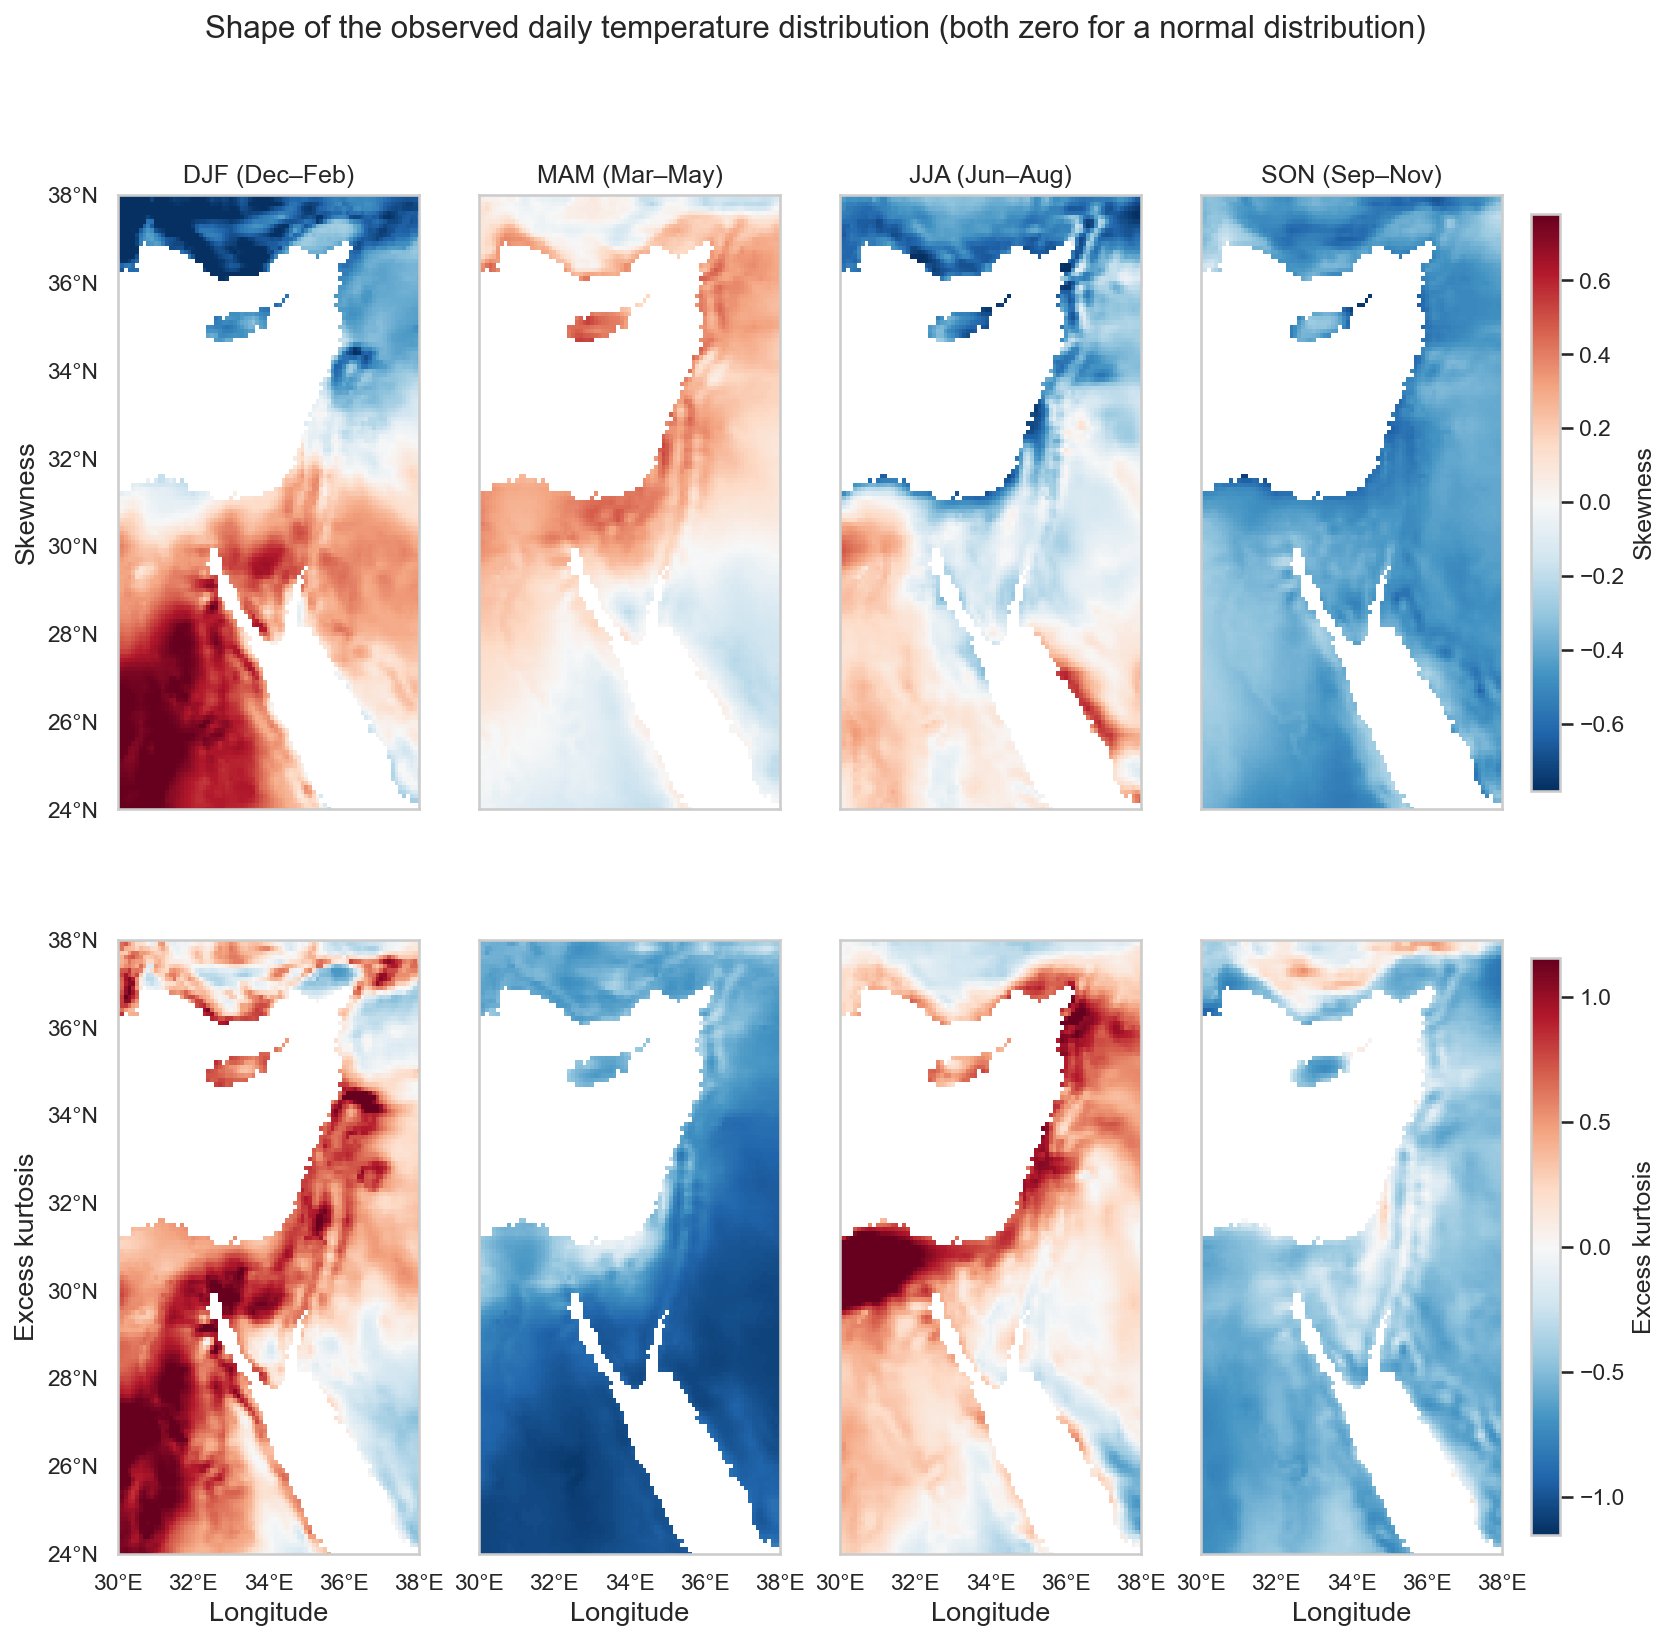

In [4]:
inp_lats = np.sort(pixels["lat"].unique())[::-1]
inp_lons = np.sort(pixels["lon"].unique())

fig = tviz.plot_moments_maps(
    moments, inp_lats, inp_lons,
    metrics=("skew", "kurtosis"), seasons=SEASONS, region=REGION,
    save_path=PLOT_DIR / "fig_q12_daily_moments.png",
)
plt.show()

**Fig. 1.** *Shape of the observed daily temperature distribution, by season.*
Top row: skewness. Bottom row: excess kurtosis. Both are zero for a normal
distribution, and the colour scale is centred on zero, so white marks agreement
with normality and colour marks departure from it. Data: ERA5-Land daily 2 m
temperature, land pixels of the EMME domain 24–38°N 30–38°E, 1990–1999.

In [5]:
m = (moments.groupby("season", observed=True)
     .agg(skew_mean=("skew", "mean"), skew_p5=("skew", lambda s: s.quantile(0.05)),
          skew_p95=("skew", lambda s: s.quantile(0.95)),
          kurt_mean=("kurtosis", "mean"),
          kurt_p5=("kurtosis", lambda s: s.quantile(0.05)),
          kurt_p95=("kurtosis", lambda s: s.quantile(0.95)),
          frac_skew_gt_half=("skew", lambda s: (s.abs() > 0.5).mean()))
     .reindex(SEASONS).round(3))
m

,skew_mean,skew_p5,skew_p95,kurt_mean,kurt_p5,kurt_p95,frac_skew_gt_half
season,,,,,,,
DJF,0.105,-0.759,0.768,0.420,-0.303,1.134,0.370
MAM,0.095,-0.156,0.376,-0.825,-1.062,-0.454,0.002
JJA,-0.118,-0.614,0.249,0.278,-0.249,1.026,0.125
SON,-0.423,-0.551,-0.291,-0.438,-0.701,0.038,0.156


**Table 3.** *Skewness and excess kurtosis of the observed daily temperature, by
season.* Columns give the domain mean and the 5th and 95th percentiles across
land pixels, plus the fraction of pixels whose absolute skewness exceeds 0.5.
Both moments are zero for a normal distribution. Data: as Fig. 1.

The numbers above should be read against Perron and Sura (2013), who compiled
skewness and kurtosis of daily reanalysis fields globally and found the
Gaussian assumption "mostly false", with the departure differing between winter
and summer. Ruff and Neelin (2012) show the same for regional surface
temperature specifically: the tails are longer than Gaussian, which matters most
for extremes.

For this work the practical reading is narrower. A moderate departure from
normality in the tails limits what the distribution-derived transform can do at
P5 and P90, while leaving it serviceable near the median. The non-parametric
transforms make no distributional assumption at all, so the comparison in
Section 4 measures how much that assumption costs.

## 3. Method comparison

Every transform fitted on one pixel's training nodes, with the resulting `h`
drawn over the q–q scatter.

/opt/homebrew/lib/python3.10/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


pixel 50: 38.0N 35.0E | departure from a line 1.218 °C (median across pixels 0.452)


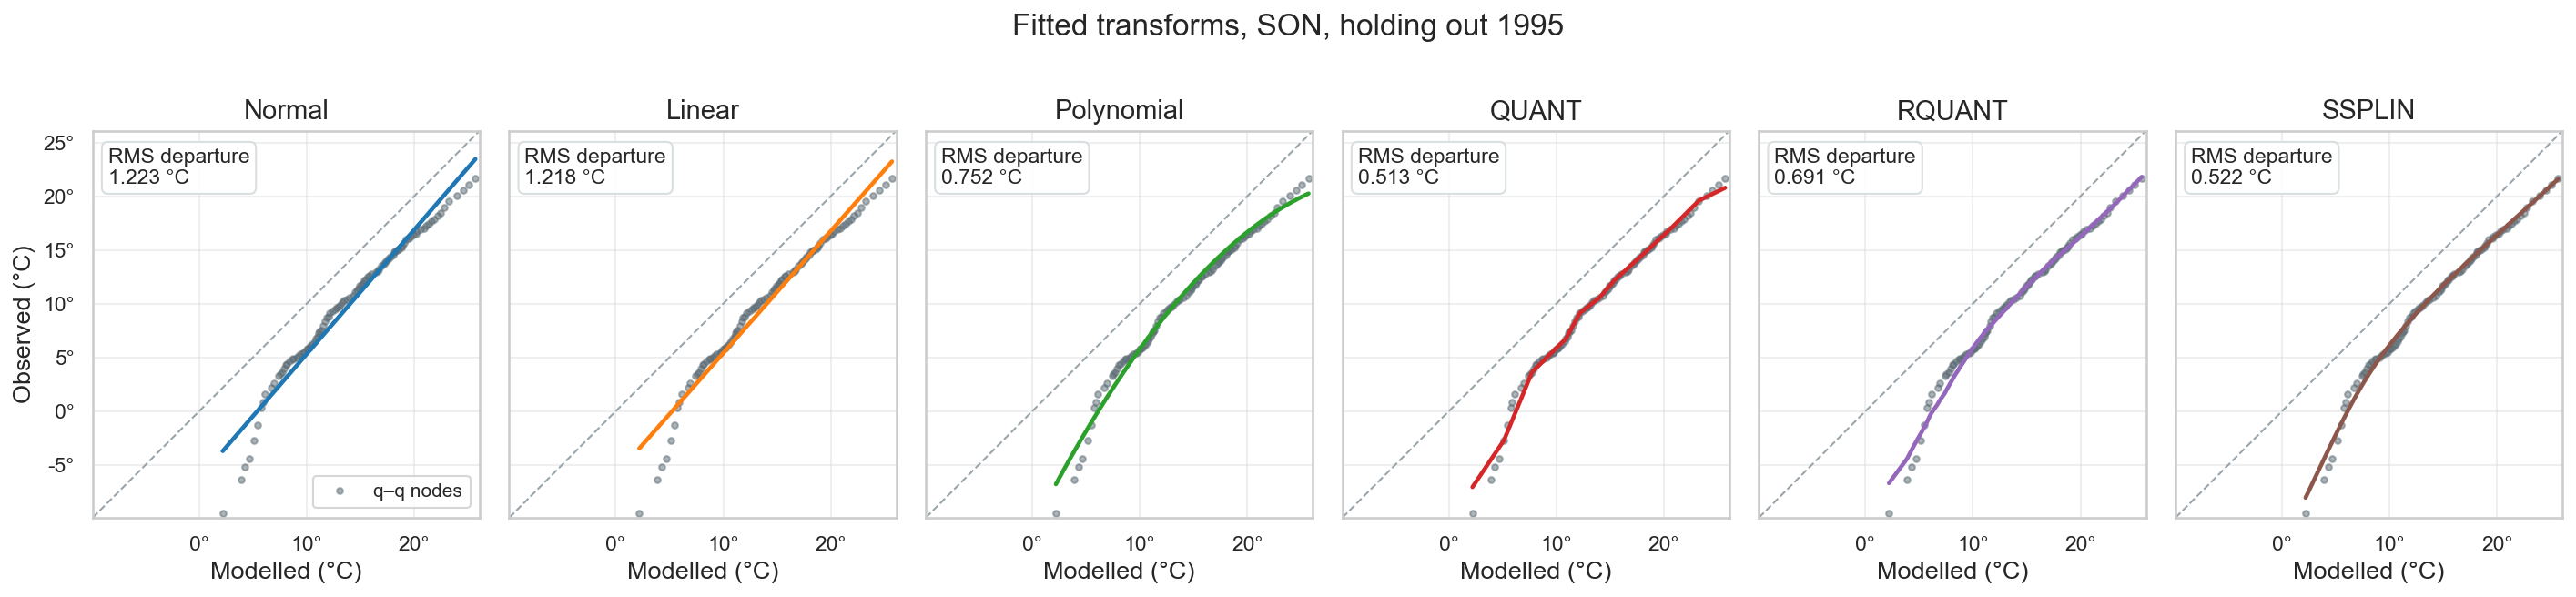

In [6]:
inp = qin.load_aligned_inputs(DATA_DIR)
bilinear = qin.load_bilinear_predictor(
    CACHE_DIR, inp["cmip_tas"], inp["era5_lats"], inp["era5_lons"],
    inp["shared_dates"],
)
daily = qn.build_daily_seasons(
    inp["era5_temp"], bilinear, list(inp["shared_dates"]), pixels,
)

FOCUS_SEASON = "SON"
FOCUS_HOLD = 1995
nodes = qn.fold_nodes(daily[FOCUS_SEASON], hold_out=FOCUS_HOLD,
                      n_nodes=manifest["config"]["n_nodes"])

hp_of = {}
if len(hyper):
    best = (hyper.sort_values("inner_mae")
            .drop_duplicates(["method", "season"]))
    for r in best.itertuples():
        if r.season == FOCUS_SEASON:
            hp_of[r.method] = json.loads(r.hp.replace("'", '"')) if r.hp != "{}" else {}

fitted = {m: TRANSFORMS[m](**hp_of.get(m, {})).fit(nodes) for m in METHODS}

# The pixel whose q-q relation departs most from a straight line, so the
# methods are visually distinguishable.  At a typical pixel they coincide.
xn = nodes.x.astype(float); yn = nodes.y.astype(float)
n = xn.shape[0]
b = (n * (xn * yn).sum(0) - xn.sum(0) * yn.sum(0)) / (n * (xn ** 2).sum(0) - xn.sum(0) ** 2)
a = (yn.sum(0) - b * xn.sum(0)) / n
rms = np.sqrt(((yn - (a + b * xn)) ** 2).mean(0))
rms[~nodes.valid] = np.nan
FOCUS_COL = int(np.nanargmax(rms))
print(f"pixel {FOCUS_COL}: {pixels.loc[FOCUS_COL, 'lat']:.1f}N "
      f"{pixels.loc[FOCUS_COL, 'lon']:.1f}E | departure from a line "
      f"{rms[FOCUS_COL]:.3f} °C (median across pixels {np.nanmedian(rms):.3f})")

fig = tviz.plot_transform_curves(
    nodes, fitted, pix_col=FOCUS_COL, season=FOCUS_SEASON, methods=METHODS,
    title=f"Fitted transforms, {FOCUS_SEASON}, holding out {FOCUS_HOLD}",
    save_path=PLOT_DIR / "fig_q13_transform_curves.png",
)
plt.show()

**Fig. 2.** *The seven fitted transforms at the domain's highest pixel.* Upper
panel: grey circles are the training q–q nodes, pairing the sorted predictor
values against the sorted observed values; the dashed line is 1:1 and each
coloured line is one fitted transform. Lower panel: the same transforms drawn as
the correction they apply, prediction minus input, so a flat line at zero would
mean no change. Data: bilinear CMIP6 predictor against ERA5-Land, JJA 1990–1999
excluding 1995, one land pixel.

## 4. Spatial distribution of error

Every number below is out of sample: for each season-year the transform was
fitted without that year and scored on it.

In [7]:
overall = (summary.groupby("method", observed=True)
           .agg(mae=("mae", "mean"), rmse=("rmse", "mean"),
                bias=("bias", "mean"), r=("pearson_r", "mean"),
                mae_floor=("mae_floor", "mean"))
           .reindex(METHODS).round(3))
overall["mae_vs_raw"] = (overall["mae"] - overall.loc["raw", "mae"]).round(3)
overall["mae_excess"] = (overall["mae"] - overall["mae_floor"]).round(3)
overall["mae_over_floor"] = (overall["mae"] / overall["mae_floor"]).round(2)
overall["family"] = [tviz.METHOD_FAMILIES[m] for m in overall.index]
overall.index = [tviz.METHOD_LABELS[m] for m in overall.index]
overall

,mae,rmse,bias,r,mae_floor,mae_vs_raw,mae_excess,mae_over_floor,family
No correction,2.132,2.788,1.395,0.846,0.89,0.000,1.242,2.40,none
Normal,1.376,1.697,0.020,0.928,0.89,-0.756,0.486,1.55,distribution derived
Linear,1.372,1.692,0.020,0.928,0.89,-0.760,0.482,1.54,parametric
Polynomial,1.371,1.686,0.028,0.928,0.89,-0.761,0.481,1.54,parametric
QUANT,1.390,1.717,0.010,0.925,0.89,-0.742,0.500,1.56,non-parametric
RQUANT,1.384,1.707,-0.011,0.926,0.89,-0.748,0.494,1.56,non-parametric
SSPLIN,1.376,1.695,0.014,0.927,0.89,-0.756,0.486,1.55,non-parametric


**Table 4.** *Cross-validated skill, averaged over the four seasons and five
percentiles.* `mae`, `rmse` and `bias` are in °C, with bias defined as prediction
minus observation. `mae_floor` is the MAE that a
climatology-only prediction achieves, which is the lowest any correction can
reach (Section 1.6). `mae_vs_raw` is the change against the uncorrected
predictor, so a negative number is an improvement. `mae_excess` is the part of
the error still in principle removable, and `mae_over_floor` is the ratio, where
1.0 would mean nothing is left to remove. Data: 7,683 land pixels, 39
season-folds, ERA5-Land and CMIP6 1990–1999.

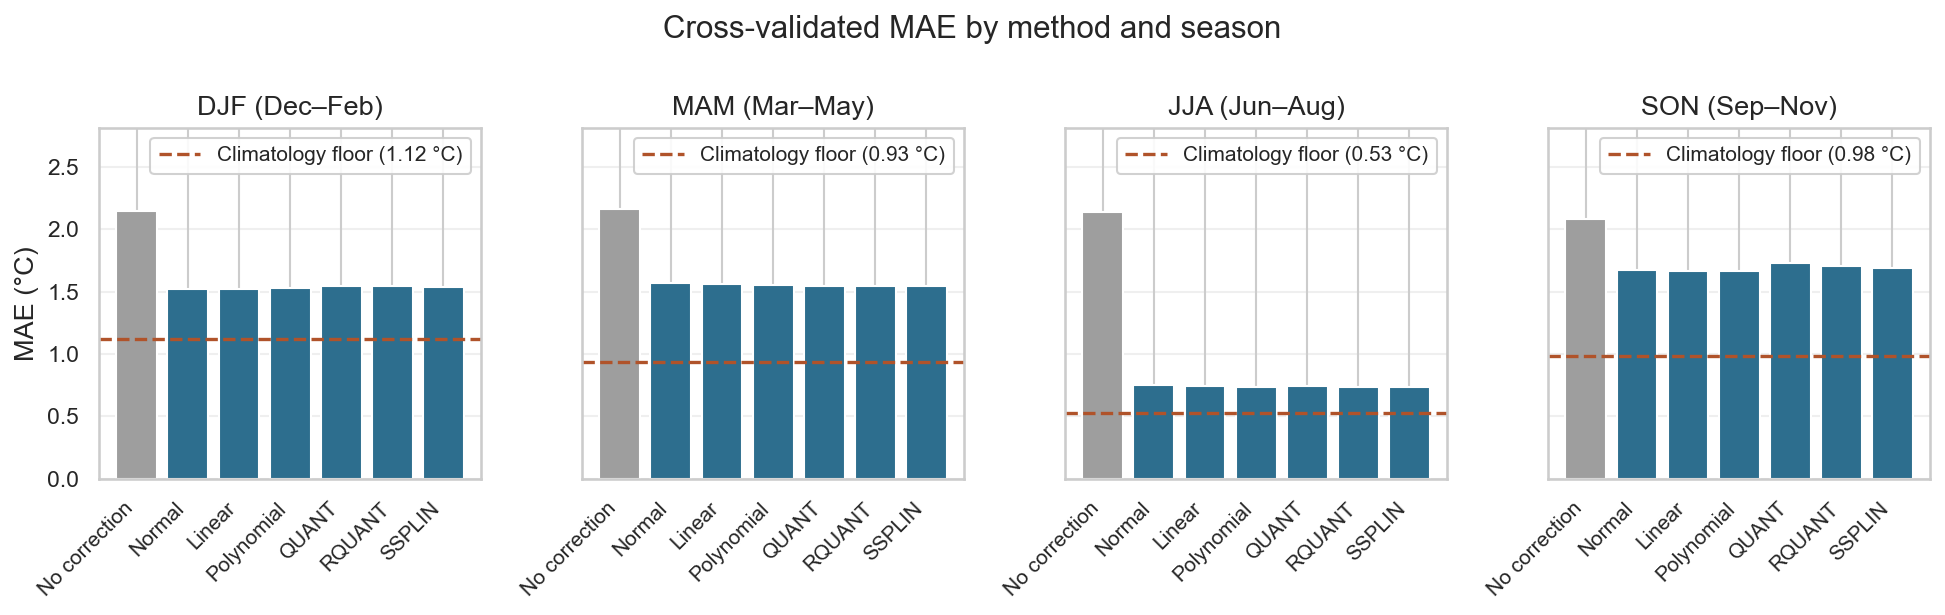

In [8]:
fig = tviz.plot_method_bars(
    summary, metric="mae", methods=METHODS, seasons=SEASONS, show_floor=True,
    save_path=PLOT_DIR / "fig_q14_method_mae_by_season.png",
)
plt.show()

**Fig. 3.** *Cross-validated MAE by method and season.* One panel per season, bars
averaged over the five percentiles. The uncorrected predictor is grey. The dashed
line marks the climatology floor: the MAE a prediction of the climatological
percentile would achieve, which is the part of the error no correction can
remove. It is drawn as a line rather than a bar because it is a property of the
observations and not a competing method.
Data: as Table 4.

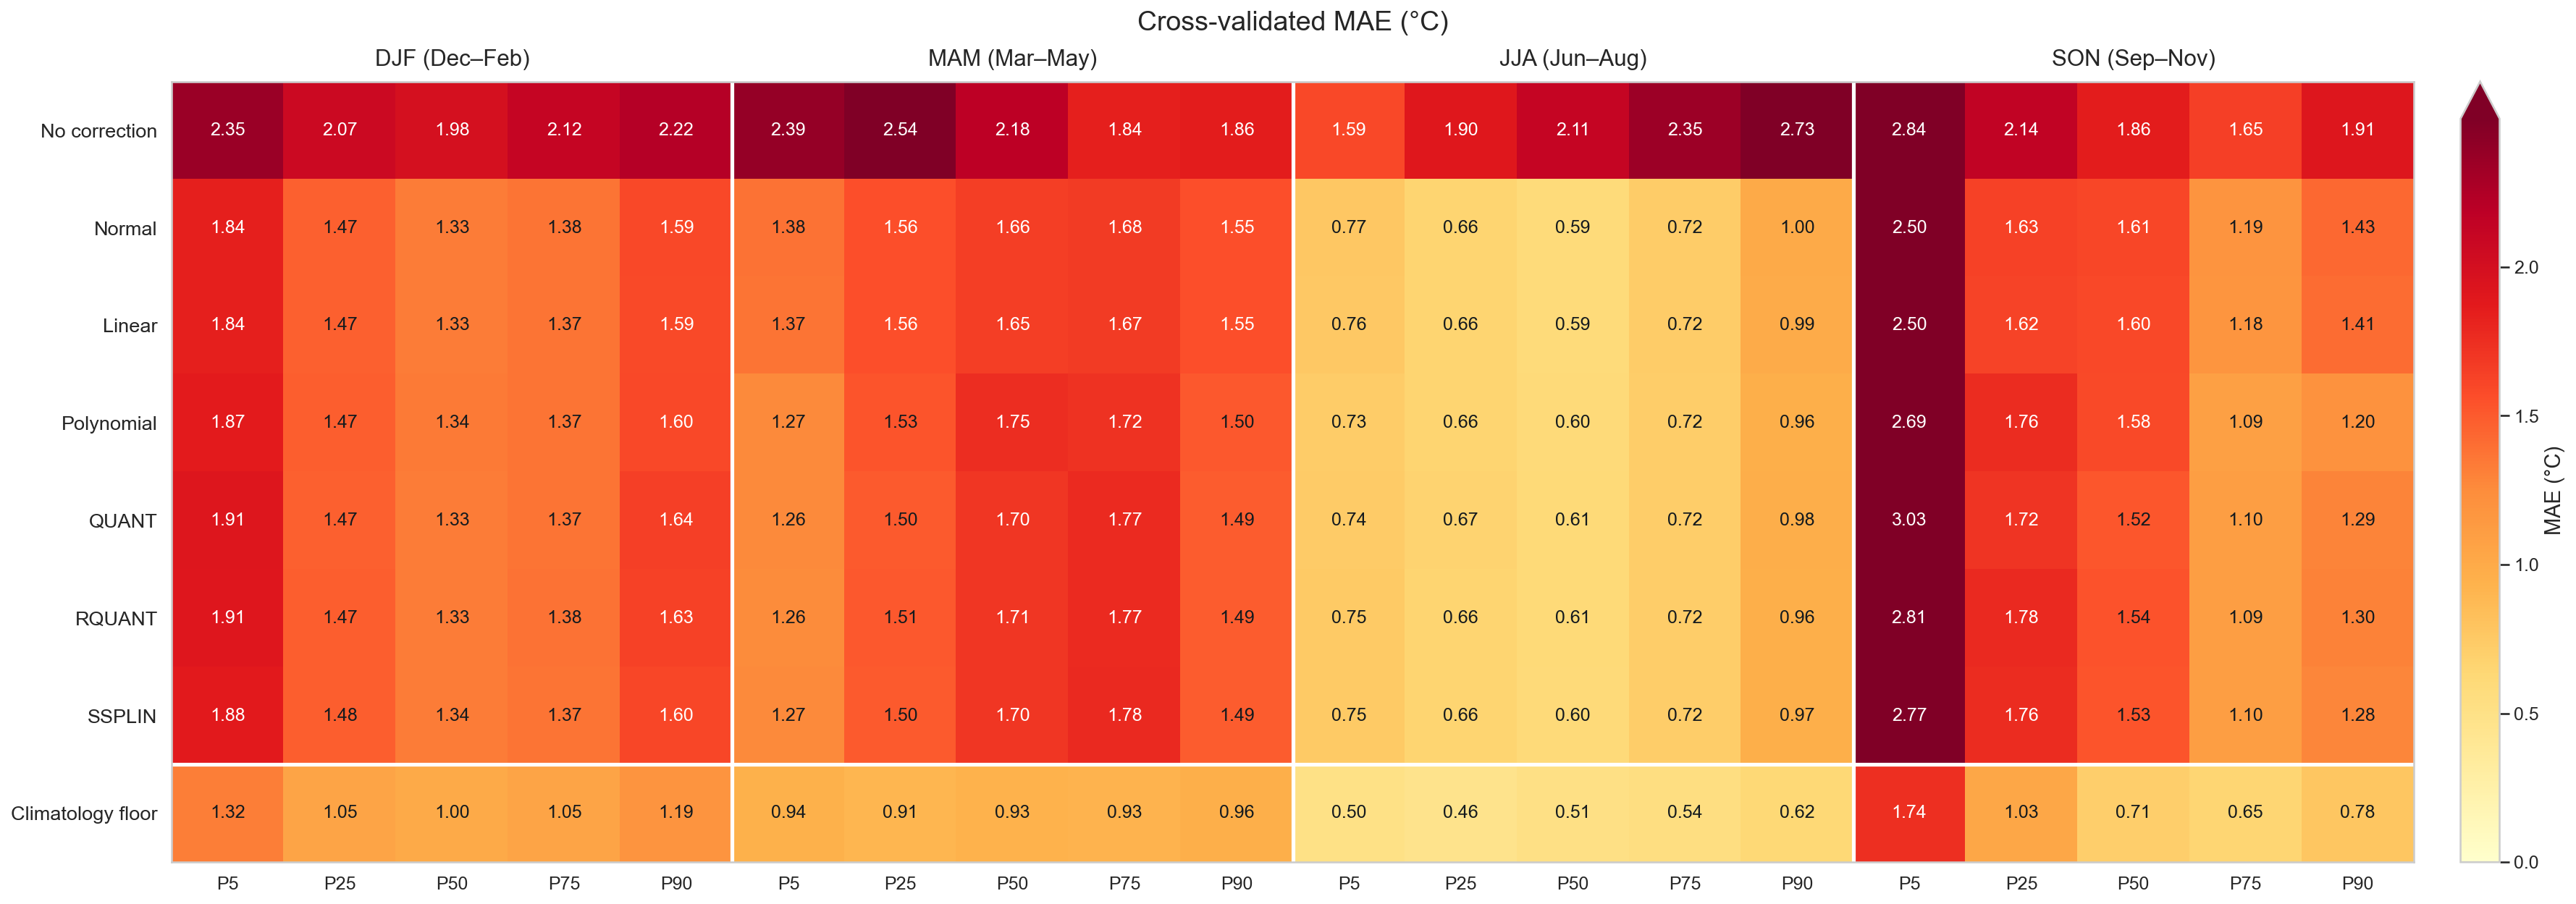

In [9]:
fig = tviz.plot_method_heatmap(
    summary, metric="mae", methods=METHODS, seasons=SEASONS,
    percentiles=PERCENTILES, show_floor=True,
    save_path=PLOT_DIR / "fig_q15_mae_heatmap.png",
)
plt.show()

**Fig. 4.** *Cross-validated MAE for every method, season and percentile.* Rows are
methods, columns are the five percentiles within each season. Cell labels are MAE
in °C. The bottom row is the climatology floor, separated by a white rule
because it is the lowest reachable error rather than a competing method. Data: as Table 4.

In [10]:
by_pct = (summary[summary["method"] != "raw"]
          .groupby("percentile", observed=True)
          .agg(mae=("mae", "mean"), floor=("mae_floor", "mean")).round(3))
by_pct["mae_over_floor"] = (by_pct["mae"] / by_pct["floor"]).round(2)
raw_pct = (summary[summary["method"] == "raw"]
           .groupby("percentile", observed=True)["mae"].mean().round(3))
by_pct.insert(0, "mae_raw", raw_pct)
by_pct

,mae_raw,mae,floor,mae_over_floor
percentile,,,,
5,2.292,1.660,1.126,1.47
25,2.162,1.343,0.863,1.56
50,2.034,1.298,0.786,1.65
75,1.988,1.237,0.791,1.56
90,2.181,1.354,0.885,1.53


**Table 5.** *Error by percentile, averaged over the seven fitted methods and the
four seasons.* `mae_raw` is the uncorrected predictor for comparison. `floor` is
the between-year standard deviation of the observed percentile at that level.
Data: as Table 4.

In [11]:
if len(hyper):
    sel = (hyper.sort_values("inner_mae").drop_duplicates(["method", "season"])
           .pivot(index="method", columns="season", values="hp")
           .reindex([m for m in METHODS if m in set(hyper["method"])]))
    sel.index = [tviz.METHOD_LABELS[m] for m in sel.index]
    margin = (hyper.sort_values("inner_mae").groupby(["method", "season"])
              .head(2).groupby(["method", "season"])["inner_mae"]
              .agg(lambda s: s.iloc[-1] - s.iloc[0]))
    print(f"Median gap between the chosen setting and the runner-up: "
          f"{margin.median():.4f} C")
    display(sel)

Median gap between the chosen setting and the runner-up: 0.0040 C


season,DJF,JJA,MAM,SON
Polynomial,{'degree': 2},{'degree': 5},{'degree': 5},{'degree': 2}
QUANT,{'n_nodes': 11},{'n_nodes': 99},{'n_nodes': 19},{'n_nodes': 11}
RQUANT,{'wsize': 65},{'wsize': 25},{'wsize': 15},{'wsize': 65}
SSPLIN,{'lam': 100.0},{'lam': 10.0},{'lam': 0.1},{'lam': 100.0}


**Table 6.** *Hyper-parameter chosen per method and season.* Selected by inner
leave-one-season-year-out cross-validation over a 400-pixel sample, using the
training years only. The gap to the runner-up is printed above the table: a small
gap means the choice barely matters, which is itself a result. Data: as Table 4.

## 5. Fit diagnostics and error floor

The aggregates above say how large the error is. The maps below say where, which
is what shows whether a correction removed the terrain-linked pattern the
uncorrected predictor has.

Methods tied on MAE (within 0.01 °C of the lowest):
  Polynomial   1.3714 °C
  Linear       1.3719 °C (monotone by construction)
  Normal       1.3764 °C (monotone by construction)
  SSPLIN       1.3764 °C

Shown below: Linear


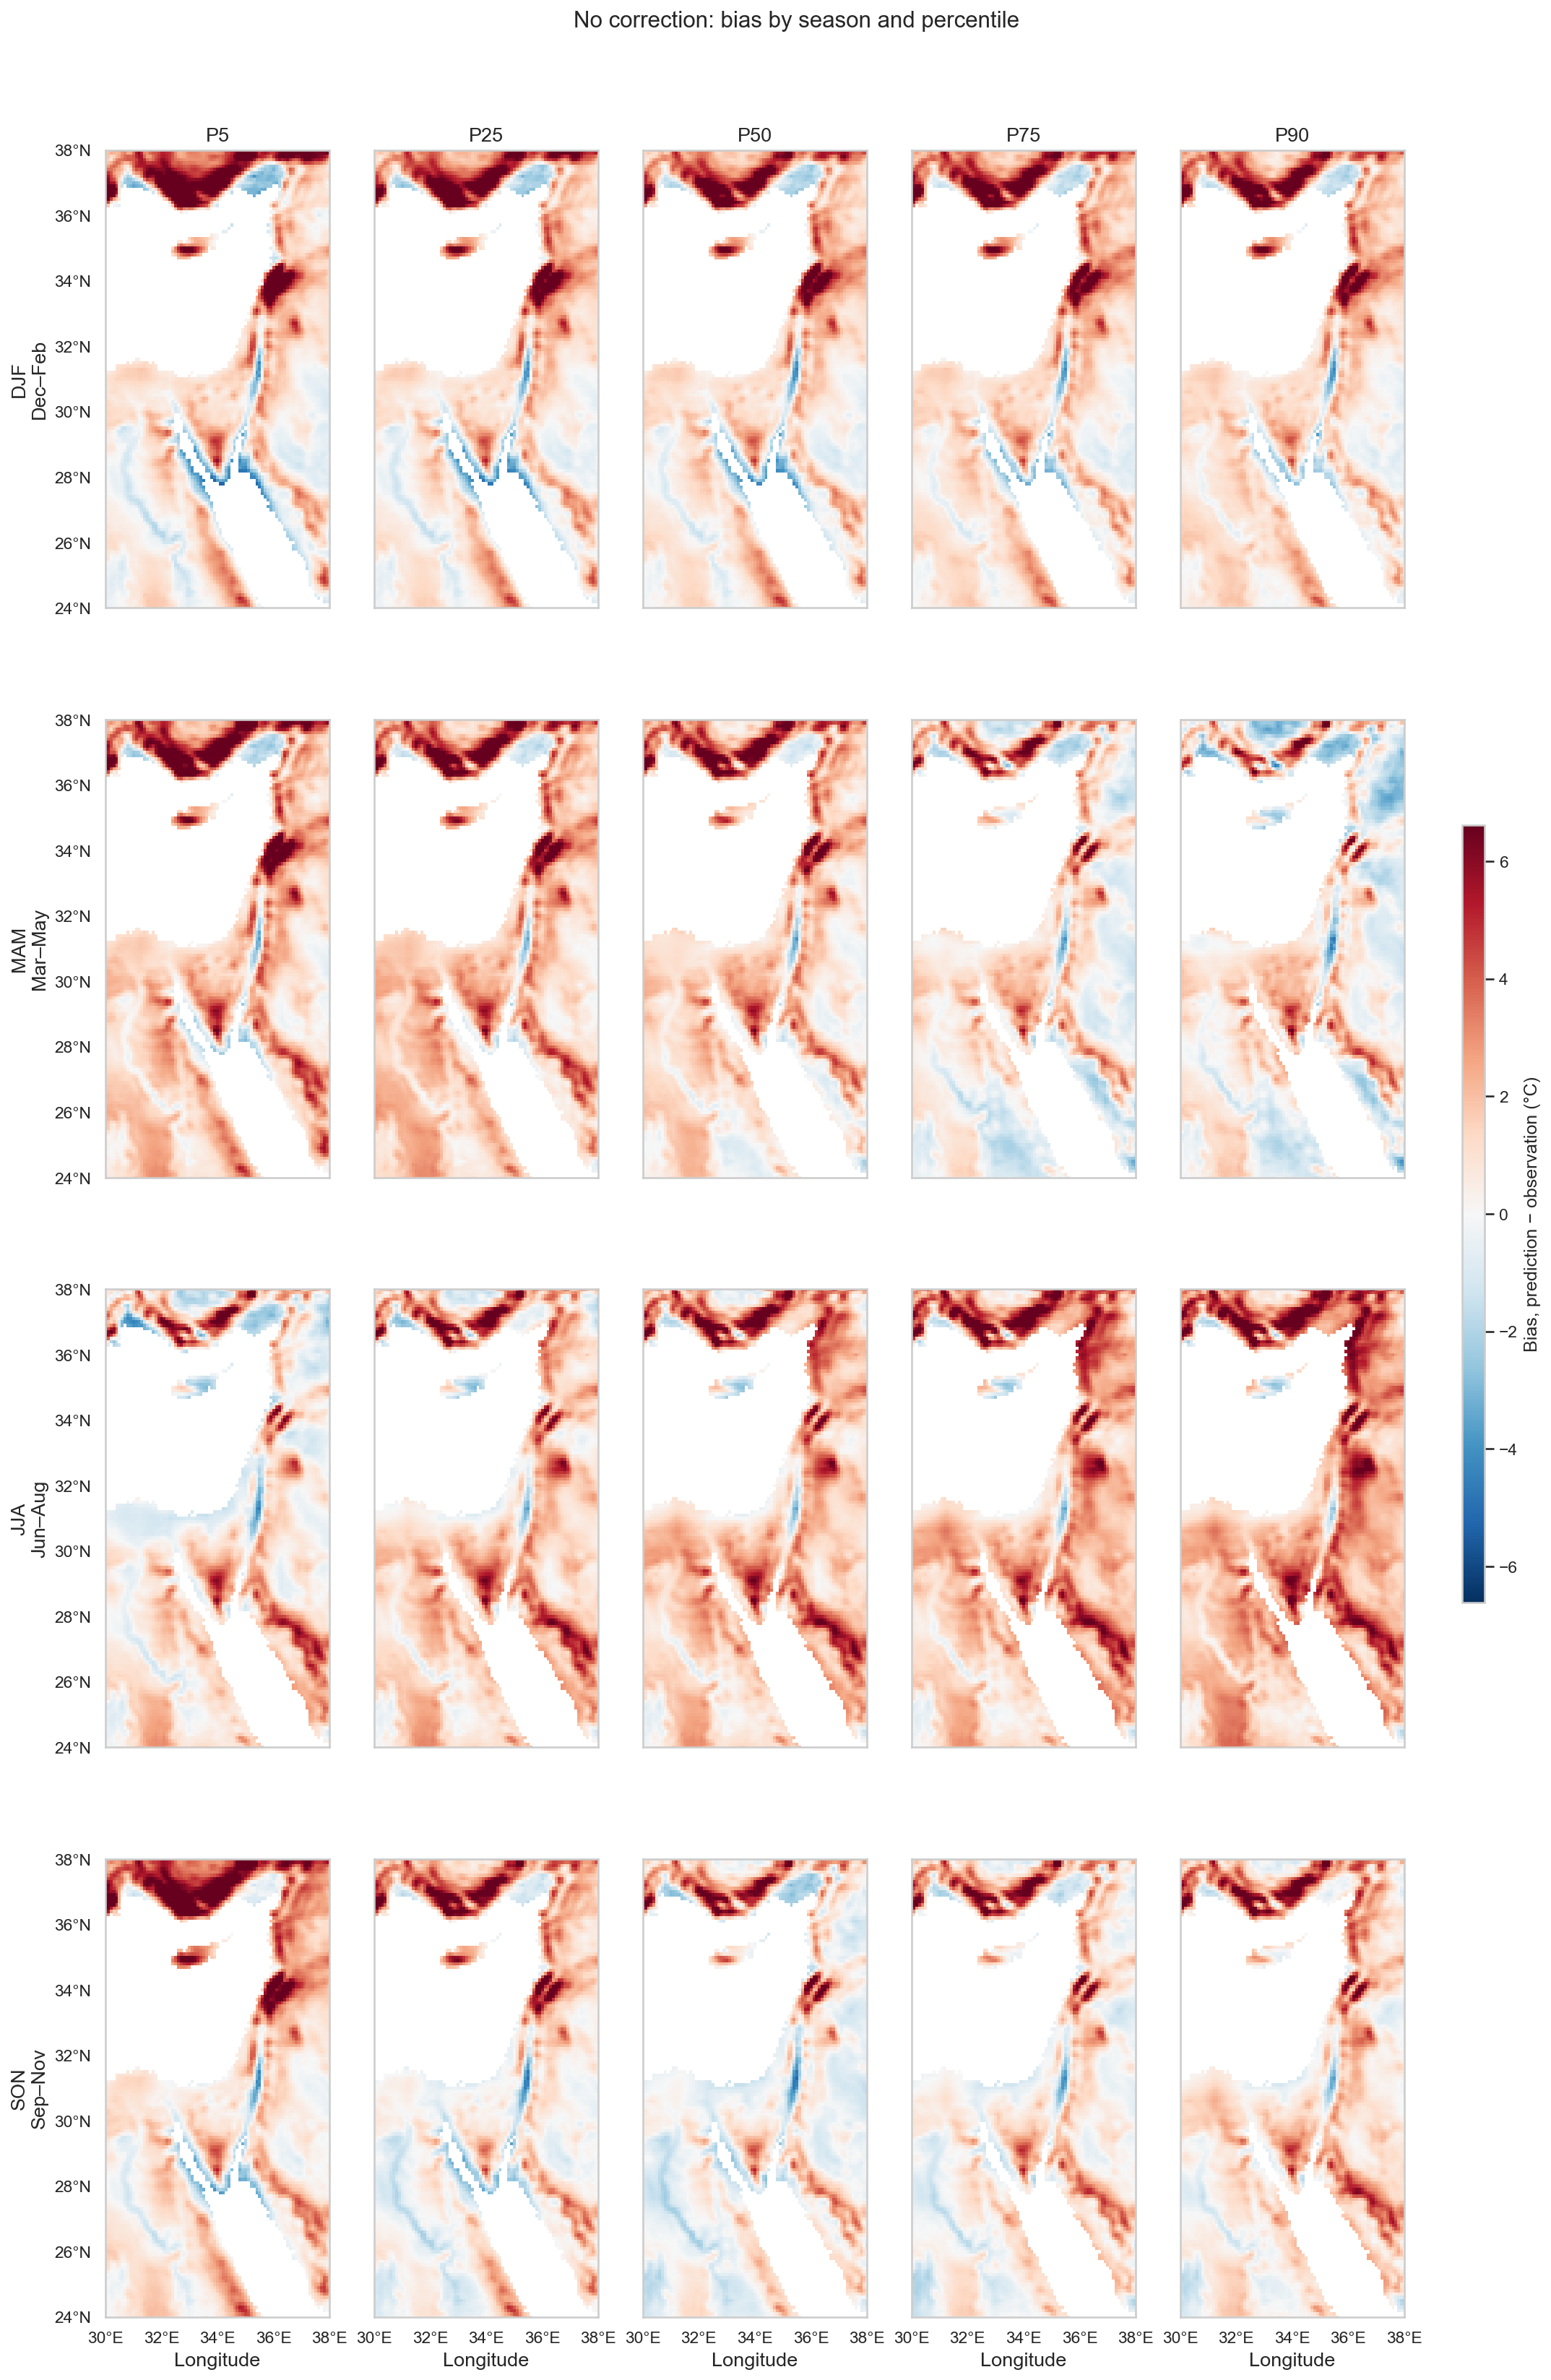

In [12]:
# The methods finish within 0.03 C of each other, so picking by raw idxmin
# would turn a 0.0001 C difference into a ranking. Take every method within
# 0.01 C of the lowest as tied, then prefer one that is increasing by
# construction and so never needs the monotonicity repair.
mae_by_method = (summary[summary["method"] != "raw"]
                 .groupby("method", observed=True)["mae"].mean().sort_values())
tied = mae_by_method[mae_by_method <= mae_by_method.min() + 0.01]
MONOTONE_BY_DESIGN = ["linear", "normal", "quant", "rquant"]
BEST = next((m for m in MONOTONE_BY_DESIGN if m in tied.index), tied.index[0])

print("Methods tied on MAE (within 0.01 °C of the lowest):")
for m, v in tied.items():
    mono = " (monotone by construction)" if m in MONOTONE_BY_DESIGN else ""
    print(f"  {tviz.METHOD_LABELS[m]:12s} {v:.4f} °C{mono}")
print()
print(f"Shown below: {tviz.METHOD_LABELS[BEST]}")

fig = tviz.plot_error_map_panels(
    pixel_err, inp_lats, inp_lons, method="raw", metric="mean_bias",
    seasons=SEASONS, percentiles=PERCENTILES, region=REGION,
    suptitle="No correction: bias by season and percentile",
    save_path=PLOT_DIR / "fig_q16_bias_maps_raw.png",
)
plt.show()

**Fig. 5.** *Bias of the uncorrected bilinear predictor, by season and percentile.*
Rows are seasons, columns percentiles. Colour is prediction minus observation in
°C on a scale centred on zero and shared across all panels, so red marks the
predictor being too warm and the panels are directly comparable. Data: as Table 4.

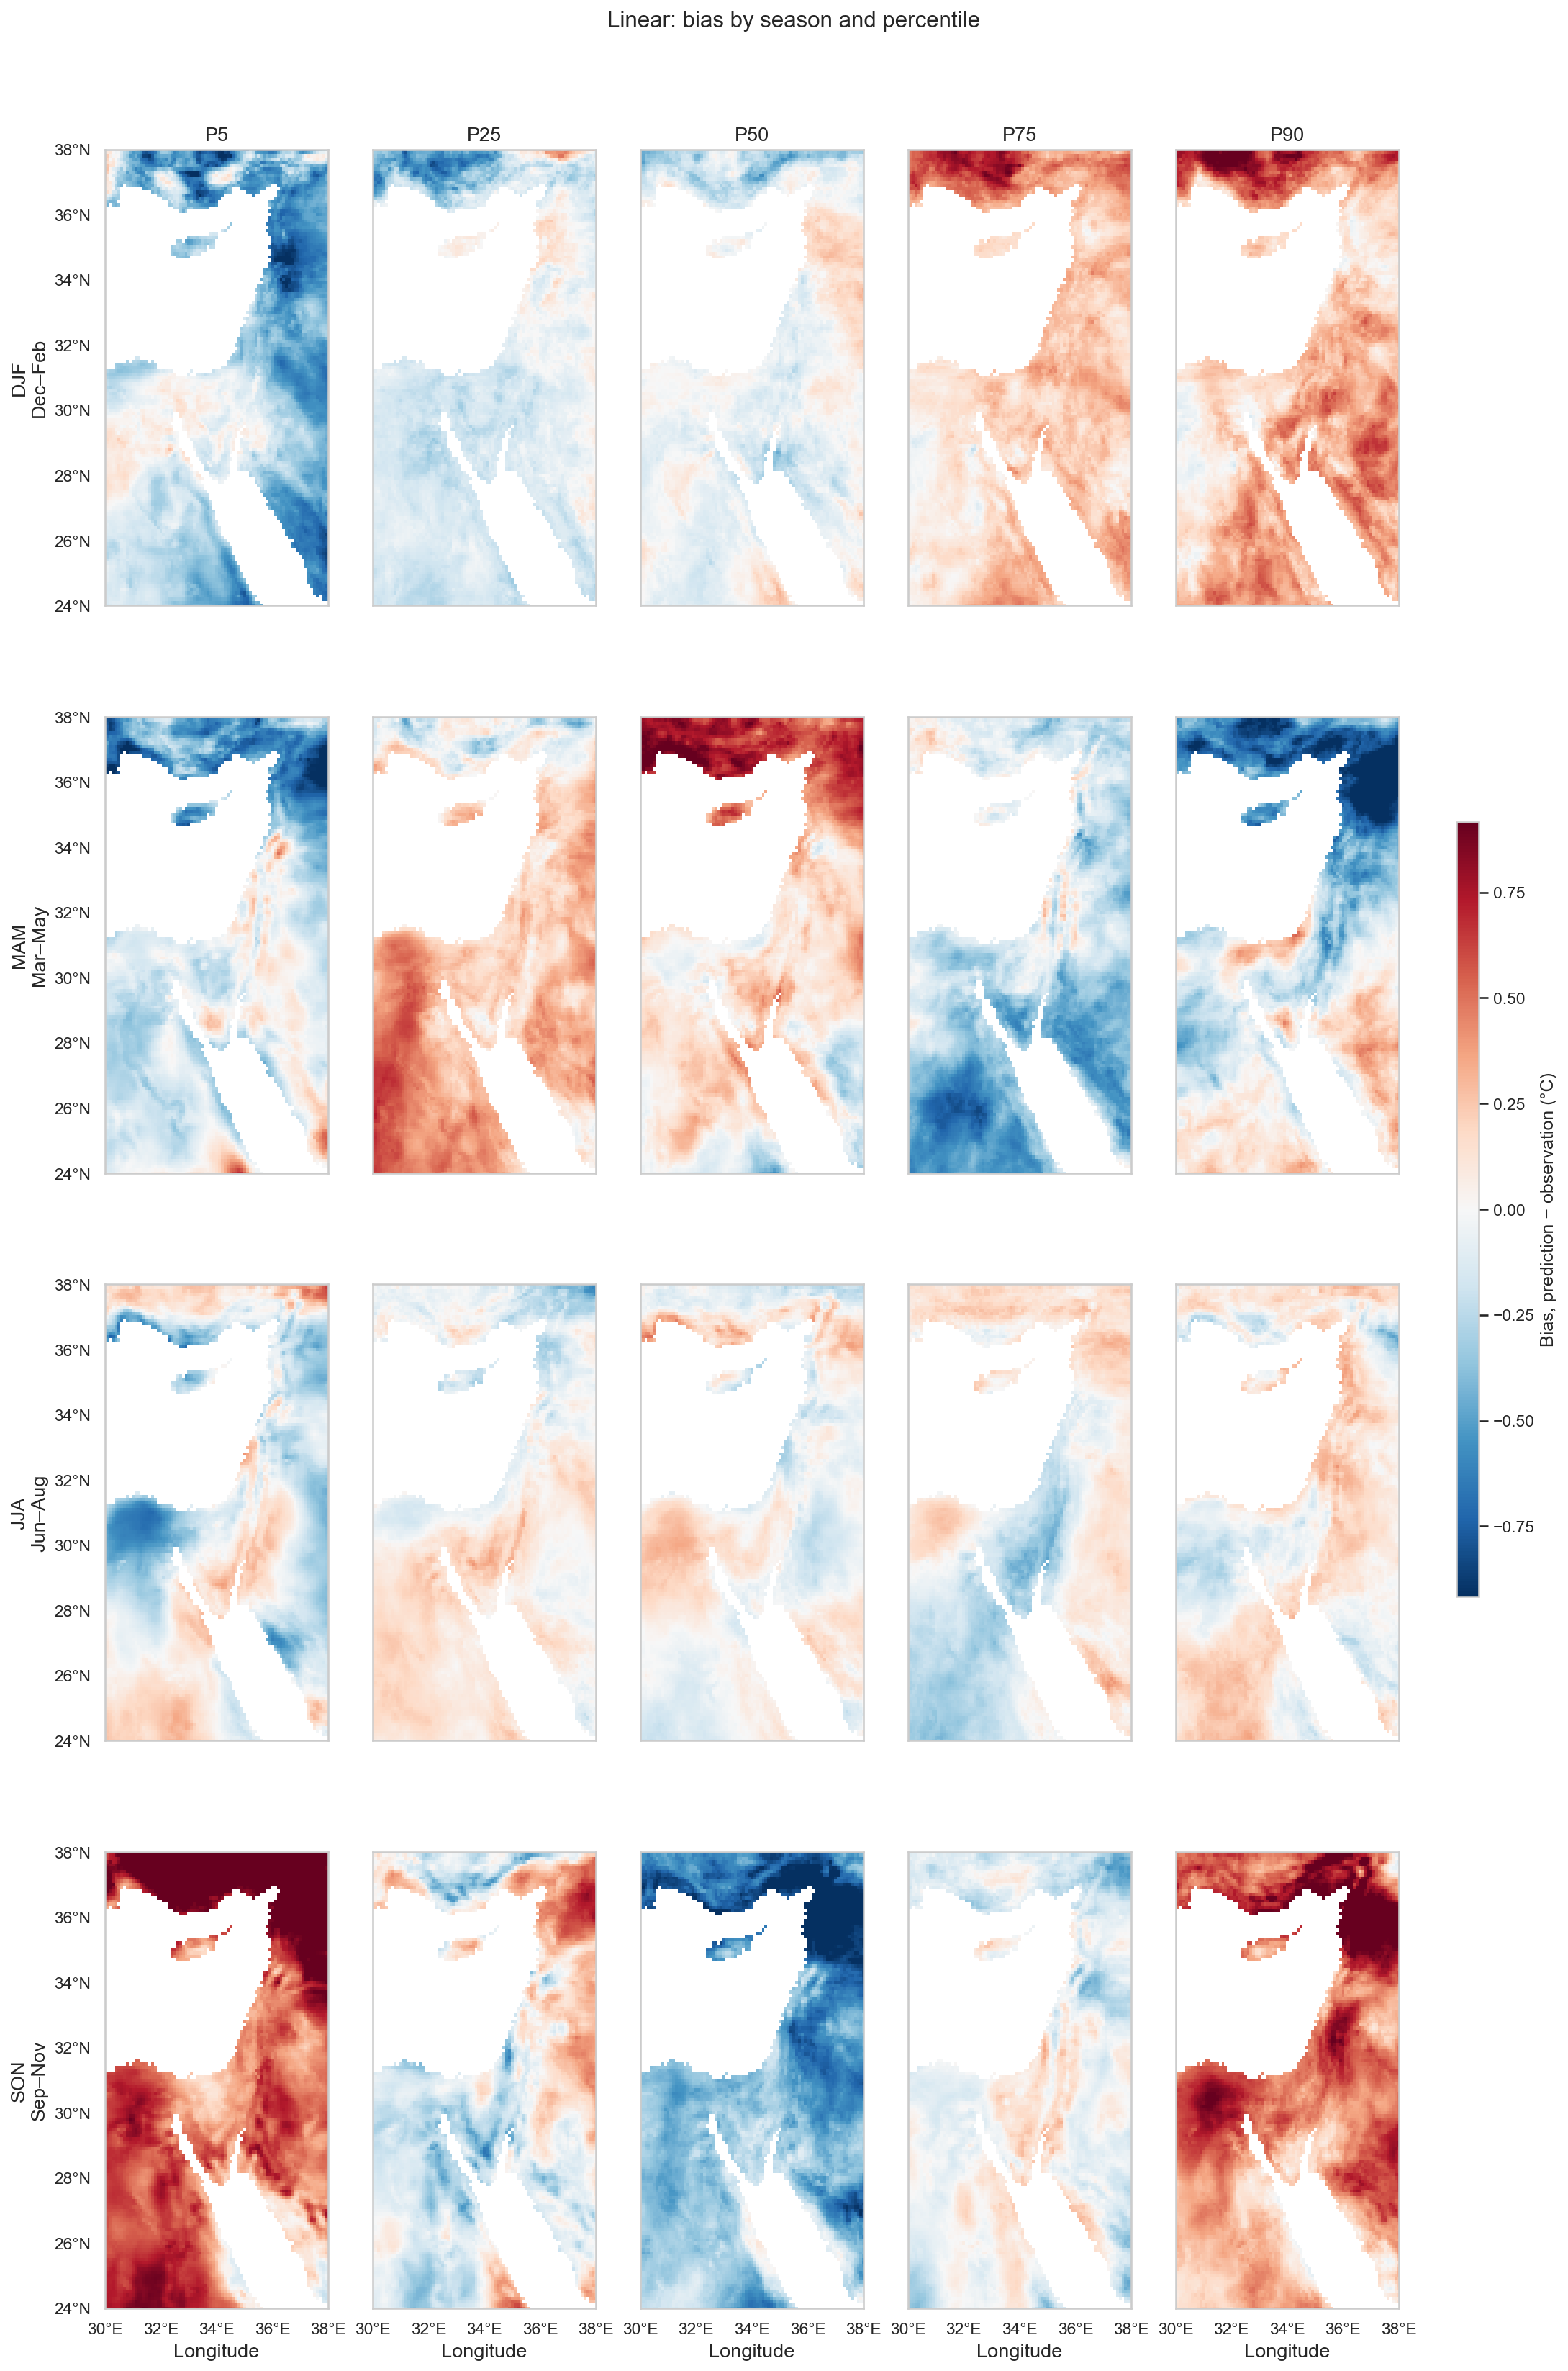

In [13]:
fig = tviz.plot_error_map_panels(
    pixel_err, inp_lats, inp_lons, method=BEST, metric="mean_bias",
    seasons=SEASONS, percentiles=PERCENTILES, region=REGION,
    suptitle=f"{tviz.METHOD_LABELS[BEST]}: bias by season and percentile",
    save_path=PLOT_DIR / "fig_q17_bias_maps_best.png",
)
plt.show()

**Fig. 6.** *Bias after correction.* The method shown is the one printed above the
figure: of those tied on MAE, the one that is increasing by construction. Panel
layout, colour scale and sign convention as Fig. 5, so the two figures can be
compared directly. Data: as Table 4.

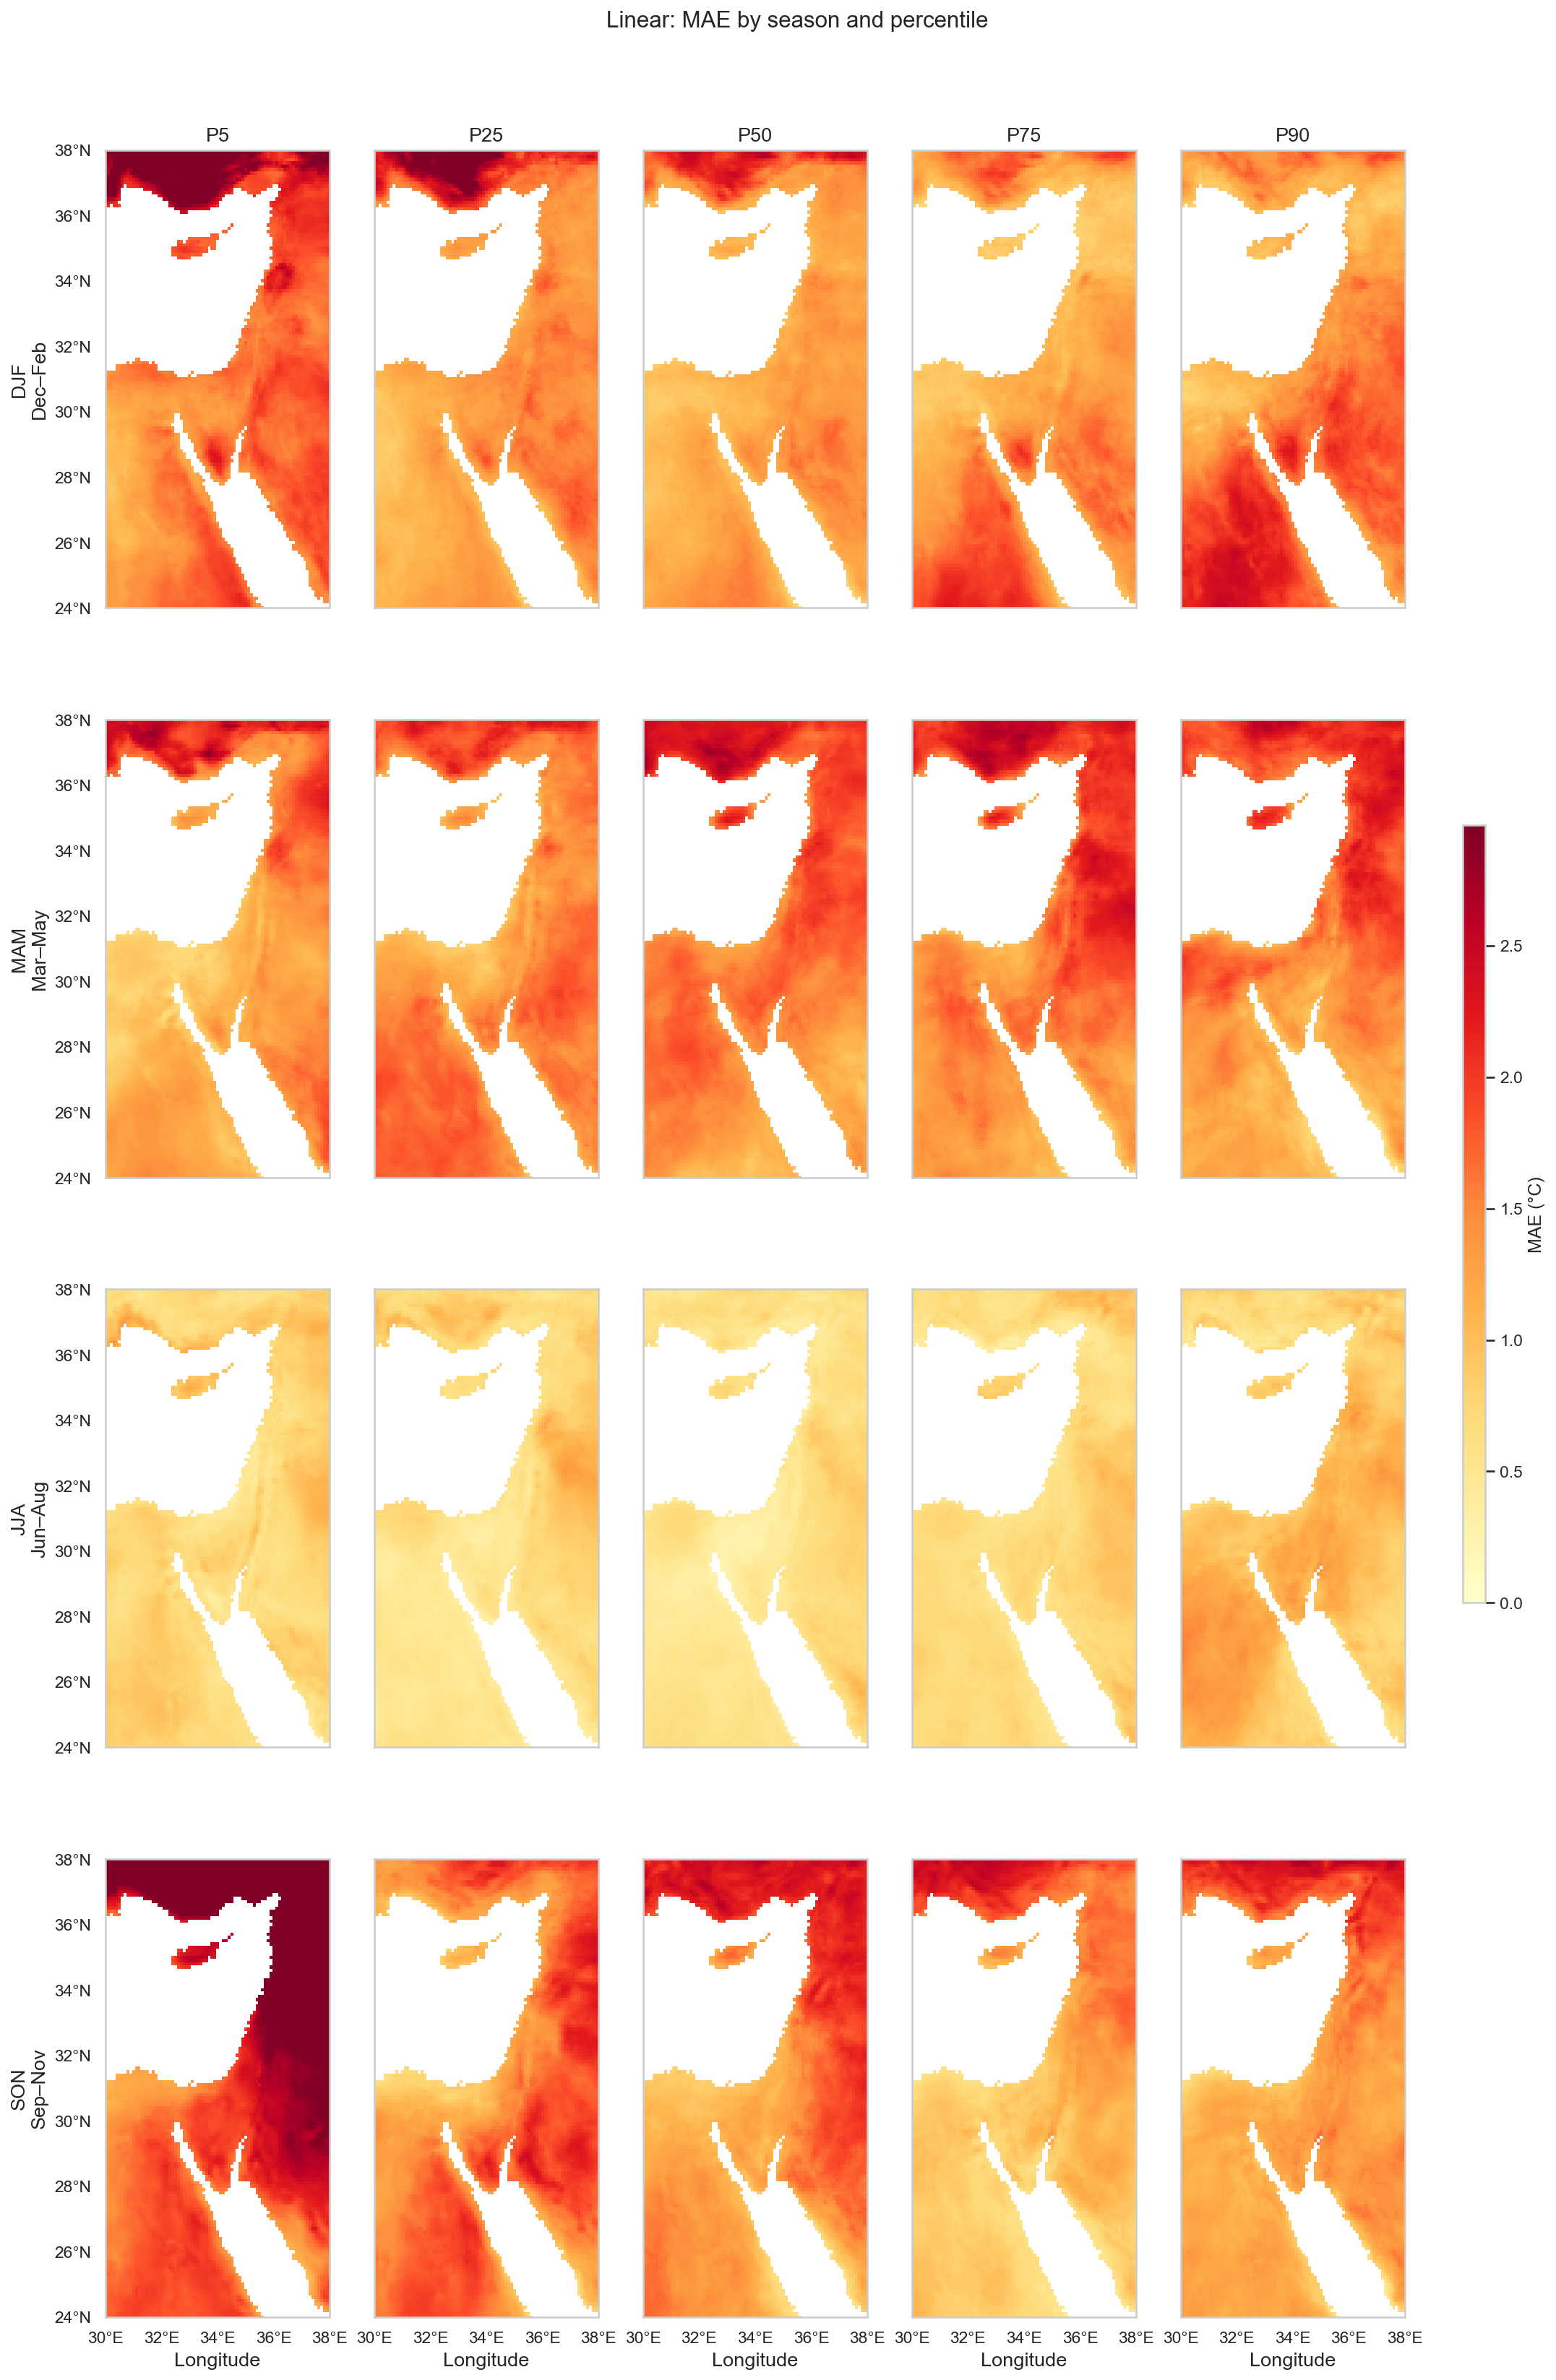

In [14]:
fig = tviz.plot_error_map_panels(
    pixel_err, inp_lats, inp_lons, method=BEST, metric="mae",
    seasons=SEASONS, percentiles=PERCENTILES, region=REGION,
    suptitle=f"{tviz.METHOD_LABELS[BEST]}: MAE by season and percentile",
    save_path=PLOT_DIR / "fig_q18_mae_maps_best.png",
)
plt.show()

**Fig. 7.** *Absolute error after correction, for the same method as Fig. 6.* Colour
is MAE in °C on a sequential scale starting at zero and shared across panels.
Unlike the bias maps, this does not cancel between years, so it shows where the
correction leaves the largest residual error rather than where it is
systematically warm or cold. Data: as Table 4.

In [15]:
static = pd.read_parquet(QM_DIR / "static_pixels.parquet")
pe = pixel_err.merge(static[["lat", "lon", "elevation", "sea_fraction"]],
                     on=["lat", "lon"], how="left")
rows = []
for m in METHODS:
    sub = pe[(pe["method"] == m) & (pe["percentile"] == 50)]
    rows.append({
        "method": tviz.METHOD_LABELS[m],
        "corr(|bias|, elevation)": sub["mean_bias"].abs().corr(sub["elevation"]),
        "corr(mae, elevation)": sub["mae"].corr(sub["elevation"]),
        "corr(mae, sea fraction)": sub["mae"].corr(sub["sea_fraction"]),
        "mae, lowest elevation quintile": sub.loc[
            sub["elevation"] <= sub["elevation"].quantile(0.2), "mae"].mean(),
        "mae, highest elevation quintile": sub.loc[
            sub["elevation"] >= sub["elevation"].quantile(0.8), "mae"].mean(),
    })
terrain = pd.DataFrame(rows).set_index("method").round(3)
terrain

,"corr(|bias|, elevation)","corr(mae, elevation)","corr(mae, sea fraction)","mae, lowest elevation quintile","mae, highest elevation quintile"
method,,,,,
No correction,0.619,0.666,0.020,1.435,3.481
Normal,0.192,0.301,-0.096,1.102,1.556
Linear,0.192,0.301,-0.096,1.099,1.550
Polynomial,0.190,0.295,-0.105,1.115,1.574
QUANT,0.185,0.307,-0.100,1.088,1.542
RQUANT,0.165,0.300,-0.098,1.100,1.547
SSPLIN,0.153,0.298,-0.097,1.098,1.539


**Table 7.** *Relation between the median-percentile error and the terrain.*
Correlations are computed across land pixels, pooling the four seasons. The last
two columns give mean MAE in the lowest and highest fifth of the elevation
distribution. Data: as Table 4, with ETOPO elevation regridded onto the ERA5-Land
grid and the sea fraction of each parent CMIP6 cell.

## 6. Distribution shape

In [16]:
diag_files = sorted(TR_DIR.glob("qq_fit_diag_*.parquet"))
diag = pd.concat([pd.read_parquet(p) for p in diag_files], ignore_index=True)
rows = []
for m in METHODS:
    d = diag[diag["method"] == m]
    rows.append({
        "method": tviz.METHOD_LABELS[m],
        "fits": len(d),
        "non-monotone h (%)": 100 * (d["n_nonmono"] > 0).mean(),
        "fit fell back (%)": 100 * (~d["converged"].astype(bool)).mean(),
        "extrapolated at >=1 percentile (%)":
            100 * ((d["n_extrap_lo"] + d["n_extrap_hi"]) > 0).mean(),
    })
diag_table = pd.DataFrame(rows).set_index("method").round(2)
diag_table

,fits,non-monotone h (%),fit fell back (%),extrapolated at >=1 percentile (%)
method,,,,
No correction,299637,0.00,0.0,0.00
Normal,299637,0.00,0.0,19.54
Linear,299637,0.00,0.0,19.54
Polynomial,299637,7.38,0.0,19.54
QUANT,299637,0.00,0.0,19.54
RQUANT,299637,0.00,0.0,19.54
SSPLIN,299637,4.16,0.0,19.54


**Table 8.** *Fit diagnostics, over all pixels and folds.* A non-monotone transform
would allow a corrected P25 above a corrected P50; the pipeline forces the
corrected percentiles back into order, and this column counts how often that
repair was needed. "Fit fell back" is the share of fits where the optimiser did
not converge and the linear fit was substituted. The last column is the share of
fits where at least one held-out percentile fell outside the training range and
the constant-offset extrapolation rule applied. Data: as Table 4.

In [17]:
fl = (floor.groupby(["season", "percentile"], observed=True)
      .agg(mae_floor=("obs_mad", "mean"), rmse_floor=("obs_sd", "mean"))
      .round(3))
print("MAE floor (mean absolute deviation across years):")
display(fl["mae_floor"].unstack().reindex(SEASONS))
print()
print("RMSE floor (standard deviation across years):")
display(fl["rmse_floor"].unstack().reindex(SEASONS))

MAE floor (mean absolute deviation across years):


percentile,5,25,50,75,90
season,,,,,
DJF,1.320,1.052,0.998,1.050,1.186
MAM,0.941,0.907,0.931,0.925,0.957
JJA,0.502,0.465,0.510,0.540,0.620
SON,1.740,1.029,0.705,0.649,0.778



RMSE floor (standard deviation across years):


percentile,5,25,50,75,90
season,,,,,
DJF,1.771,1.458,1.431,1.469,1.605
MAM,1.235,1.210,1.182,1.180,1.268
JJA,0.670,0.628,0.676,0.718,0.816
SON,2.234,1.234,0.973,0.881,1.026


**Table 9.** *The climatology floor, in °C.* Upper table: mean absolute deviation
of the observed percentile about its across-year median, which is the MAE a
prediction of the climatological percentile achieves. Lower table: standard
deviation about the mean, the corresponding RMSE. Computed across the 10
season-years at each pixel (9 for DJF), then averaged over land pixels. Two
quantities are needed because for a roughly normal sample the mean absolute
deviation is about 0.8 of the standard deviation, so comparing an MAE against a
standard deviation would understate it. Data: ERA5-Land daily 2 m temperature,
1990–1999.

In [18]:
best_row = (summary[summary["method"] == BEST]
            .groupby("season", observed=True)
            .agg(mae=("mae", "mean"), floor=("mae_floor", "mean")))
best_row["excess_over_floor"] = best_row["mae"] - best_row["floor"]
best_row["ratio"] = best_row["mae"] / best_row["floor"]
print(f"Method: {tviz.METHOD_LABELS[BEST]}")
print(best_row.round(3).to_string())

raw_mae = summary.loc[summary["method"] == "raw", "mae"].mean()
best_mae = summary.loc[summary["method"] == BEST, "mae"].mean()
fl_mean = summary["mae_floor"].mean()
print(f"\nUncorrected MAE      {raw_mae:.3f} C")
print(f"Best corrected MAE   {best_mae:.3f} C  "
      f"({100 * (1 - best_mae / raw_mae):.0f}% lower)")
print(f"Irreducible floor    {fl_mean:.3f} C")
print(f"Removable error left {best_mae - fl_mean:.3f} C")

Method: Linear
          mae  floor  excess_over_floor  ratio
season                                        
DJF     1.519  1.121              0.398  1.355
MAM     1.563  0.932              0.630  1.676
JJA     0.745  0.527              0.217  1.412
SON     1.661  0.980              0.680  1.694

Uncorrected MAE      2.132 C
Best corrected MAE   1.372 C  (36% lower)
Irreducible floor    0.890 C
Removable error left 0.482 C


**Table 10.** *Error against the climatology floor, by season, for the best
method.* `mae` and `floor` are in °C. `excess_over_floor` is the part of the
error that is in principle still removable, and `ratio` is MAE divided by the
floor. Data: as Table 4.

### Summary

Applying a correction reduces MAE from 2.132 to 1.372 °C, a 36 % reduction in
total error and 61 % of the error above the climatology floor. The uncorrected
bias of +1.395 °C falls to between −0.011 and +0.026 °C for every method.

The six transforms span 0.018 °C on MAE. The best method changes from percentile
to percentile with margins of 0.001 to 0.018 °C, so the comparison does not
separate them. The two-parameter linear fit matches the degree-5 polynomial, the
smoothing spline and the 99-node empirical lookup, while being increasing by
construction and having no hyper-parameter.

Most of the residual error is irreducible. The climatology floor is 0.890 °C
against the best method's 1.372 °C, so the methods compete over 0.482 °C. JJA's
MAE of 0.743 °C against SON's 1.660 °C reflects the floors, 0.527 and 0.980 °C,
rather than a difference in how well the correction works.

The hyper-parameter selections move towards the smoothest available setting in
DJF and SON, the noisiest seasons, and the empirical lookups finish behind the
linear fit. Gudmundsson et al. (2012) state that overfitting "may be an issue if
the nonparametric transformations are calibrated using small data samples";
Lehner et al. (2023) report that "non-parametric QM depends more on the
calibration period than parametric QM".

SON P5 is the hardest cell. The floor is 1.740 °C, the best method removes 31 %
of the removable error, and QUANT performs worse than no correction. It is also
the season with the largest departure from normality.

### Caveats

- **The climatology floor is slightly optimistic.** It is computed from every
  year, including the one being predicted, so a leave-one-out version would be a
  little larger and the excess above it correspondingly smaller.
- **Ten years is a short calibration record.** Lehner et al. (2023) call 30 years
  typical, precisely because shorter records give noisy distributions. Every skill
  number here should be read with that in mind, and the tails most of all.
- **The supporting studies are on precipitation.** Reiter et al. (2018) and
  Gudmundsson et al. (2012) both test precipitation, which is bounded at zero,
  intermittent and far more skewed than temperature. The shape of their
  trade-offs transfers; the specific optima do not.
- **Cross-validation measures sampling error, not transferability.** Every fold
  comes from the same decade and the same climate, so this design cannot say
  whether a transform still holds in 2081–2100. Only the held-out future periods
  can speak to that.
- **DJF rests on one fewer fold** than the other seasons, so its numbers are
  slightly less well determined.
- **Quantile mapping across this resolution gap is not downscaling.** Maraun
  (2013) shows that mapping a grid-box distribution onto much finer observations
  adds no sub-grid variability and inflates the series instead. Our gap is about
  tenfold. He notes the effect is weaker for temperature, which is spatially
  coherent and whose small-scale variation is largely orographic and therefore
  correctable — but it is a caveat, not an exemption.
- **ERA5-Land is not an independent fine-scale observation.** It is a model
  reanalysis whose forcing was already height-corrected, so part of the elevation
  signal was put there by ECMWF rather than observed.